In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import chi2_contingency, pearsonr, spearmanr
from sklearn.feature_selection import mutual_info_classif, chi2, f_classif
from scipy.stats import pearsonr, spearmanr
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split

# delete (...)
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None) 


In [51]:
df = pd.read_csv('group_26_train.csv')

In [52]:
#number of samples and features
print("Dataset Shape:", df.shape)

df.head(5)

Dataset Shape: (100000, 35)


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y
0,Source2,2018-03-30 17:32:46,40.810566,-73.256042,NaN,NaN,0.000,Commerce Dr,Hauppauge,Suffolk,NY,11788-3968,KISP,52.0,NaN,29.77,10.0,NNW,13.8,0.01,Overcast,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,2
1,Source1,2022-07-27 13:42:00,45.358867,-122.762271,45.341362,-122.768971,1.252,I-5 S,Tualatin,Washington,OR,97062,KUAO,90.0,90.0,29.78,10.0,NNE,3.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
2,Source1,2022-06-06 13:00:30,41.233610,-95.954493,41.242050,-95.953603,0.585,US-75,Omaha,Douglas,NE,68105,KOMA,76.0,76.0,28.67,10.0,VAR,3.0,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2
3,Source1,2021-09-07 21:50:00,34.039947,-117.505855,34.037156,-117.505860,0.193,Ranchero Dr,Fontana,San Bernardino,CA,92337,KONT,77.0,77.0,28.89,10.0,WSW,5.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2
4,Source2,2019-05-23 20:52:35,47.230240,-122.448868,NaN,NaN,0.000,I-5 N,Tacoma,Pierce,WA,98418,KTCM,63.0,63.0,29.53,10.0,W,8.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,3


In [53]:
# type of features!
print("List of all features:")
print(df.columns.tolist())

List of all features:
['f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f15', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y']


In [54]:
print("\nDetailed feature information:")
print(df.dtypes)


Detailed feature information:
f1         str
f2         str
f3     float64
f4     float64
f5     float64
f6     float64
f7     float64
f8         str
f9         str
f10        str
f11        str
f12        str
f13        str
f14    float64
f15    float64
f16    float64
f17    float64
f18        str
f19    float64
f20    float64
f21        str
f22       bool
f23       bool
f24       bool
f25       bool
f26       bool
f27       bool
f28       bool
f29       bool
f30       bool
f31        str
f32        str
f33        str
f34        str
y        int64
dtype: object


In [55]:
dtype_counts = df.dtypes.value_counts()
print(dtype_counts)

str        14
float64    11
bool        9
int64       1
Name: count, dtype: int64


In [56]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'y']
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)

Numeric columns: 11
['f3', 'f4', 'f5', 'f6', 'f7', 'f14', 'f15', 'f16', 'f17', 'f19', 'f20']

Categorical columns: 14
['f1', 'f2', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'f31', 'f32', 'f33', 'f34']

Boolean columns: 9
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30']


In [57]:
for feature in df.columns:
    # Check if feature is boolean, object (string), or categorical integer
    if df[feature].dtype in ['bool', 'str']:
        display(df[feature].value_counts())
    else:
        # For float/int, just skip or use describe
        pass


f1
Source1    55744
Source2    42981
Source3     1275
Name: count, dtype: int64

f2
2021-02-16 06:43:35    4
2021-01-26 16:16:13    4
2021-02-04 13:00:00    3
2022-01-08 10:34:30    3
2020-09-15 13:29:30    3
                      ..
2021-02-09 16:47:40    1
2022-01-12 11:14:31    1
2021-04-02 19:09:53    1
2020-12-28 14:01:00    1
2018-09-18 10:23:23    1
Name: count, Length: 99407, dtype: int64

f8
I-95 N              1059
I-95 S               938
I-5 N                872
I-10 W               726
I-5 S                687
                    ... 
Eva Mae Dr             1
 N 12th St             1
 State Route 295       1
N Francis Ave          1
Throgs Neck Brg        1
Name: count, Length: 32428, dtype: int64

f9
Miami               2323
Houston             2224
Los Angeles         2055
Dallas              1745
Charlotte           1740
                    ... 
Rancho Dominguez       1
Stinnett               1
Jarrell                1
South Rockwood         1
Sandwich               1
Name: count, Length: 6406, dtype: int64

f10
Los Angeles      6815
Miami-Dade       3150
Orange           3147
Harris           2387
Dallas           2104
                 ... 
Early               1
Hopewell City       1
Navarro             1
Sac                 1
Hutchinson          1
Name: count, Length: 1303, dtype: int64

...

f30
False    100000
Name: count, dtype: int64

f31
Day      68859
Night    30828
Name: count, dtype: int64

f32
Day      73568
Night    26119
Name: count, dtype: int64

f33
Day      78677
Night    21010
Name: count, dtype: int64

f34
Day      82524
Night    17163
Name: count, dtype: int64

In [58]:
df['f2'] = pd.to_datetime(df['f2'], format='mixed', errors='coerce')

df['hour'] = df['f2'].dt.hour
df['dayofweek'] = df['f2'].dt.dayofweek
df['month'] = df['f2'].dt.month
df['year'] = df['f2'].dt.year

df['dayofweek'] = df['dayofweek'].astype('str')
df['month'] = df['month'].astype('str')


display(df[['f2', 'year', 'month', 'dayofweek', 'hour']].head())

df = df.drop(columns=['f2'])



,f2,year,month,dayofweek,hour
0,2018-03-30 17:32:46,2018,3,4,17
1,2022-07-27 13:42:00,2022,7,2,13
2,2022-06-06 13:00:30,2022,6,0,13
3,2021-09-07 21:50:00,2021,9,1,21
4,2019-05-23 20:52:35,2019,5,3,20


In [59]:
df.head(5)

,f1,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y,hour,dayofweek,month,year
0,Source2,40.810566,-73.256042,NaN,NaN,0.000,Commerce Dr,Hauppauge,Suffolk,NY,11788-3968,KISP,52.0,NaN,29.77,10.0,NNW,13.8,0.01,Overcast,False,False,False,False,False,False,False,True,False,Day,Day,Day,Day,2,17,4,3,2018
1,Source1,45.358867,-122.762271,45.341362,-122.768971,1.252,I-5 S,Tualatin,Washington,OR,97062,KUAO,90.0,90.0,29.78,10.0,NNE,3.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2,13,2,7,2022
2,Source1,41.233610,-95.954493,41.242050,-95.953603,0.585,US-75,Omaha,Douglas,NE,68105,KOMA,76.0,76.0,28.67,10.0,VAR,3.0,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,Day,Day,Day,Day,2,13,0,6,2022
3,Source1,34.039947,-117.505855,34.037156,-117.505860,0.193,Ranchero Dr,Fontana,San Bernardino,CA,92337,KONT,77.0,77.0,28.89,10.0,WSW,5.0,0.00,Fair,False,False,False,False,False,False,False,False,False,Night,Night,Night,Night,2,21,1,9,2021
4,Source2,47.230240,-122.448868,NaN,NaN,0.000,I-5 N,Tacoma,Pierce,WA,98418,KTCM,63.0,63.0,29.53,10.0,W,8.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,Night,Day,Day,Day,3,20,3,5,2019


In [60]:
day_night_cols = ['f31','f32', 'f33', 'f34']

for col in day_night_cols:
    df[col] = df[col].map({'Day': False, 'Night': True}).astype(bool)


In [61]:
df.head(5)

,f1,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22,f23,f24,f25,f26,f27,f28,f29,f30,f31,f32,f33,f34,y,hour,dayofweek,month,year
0,Source2,40.810566,-73.256042,NaN,NaN,0.000,Commerce Dr,Hauppauge,Suffolk,NY,11788-3968,KISP,52.0,NaN,29.77,10.0,NNW,13.8,0.01,Overcast,False,False,False,False,False,False,False,True,False,False,False,False,False,2,17,4,3,2018
1,Source1,45.358867,-122.762271,45.341362,-122.768971,1.252,I-5 S,Tualatin,Washington,OR,97062,KUAO,90.0,90.0,29.78,10.0,NNE,3.0,0.00,Fair,False,False,False,False,False,False,False,False,False,False,False,False,False,2,13,2,7,2022
2,Source1,41.233610,-95.954493,41.242050,-95.953603,0.585,US-75,Omaha,Douglas,NE,68105,KOMA,76.0,76.0,28.67,10.0,VAR,3.0,0.00,Mostly Cloudy,False,False,False,False,False,False,False,False,False,False,False,False,False,2,13,0,6,2022
3,Source1,34.039947,-117.505855,34.037156,-117.505860,0.193,Ranchero Dr,Fontana,San Bernardino,CA,92337,KONT,77.0,77.0,28.89,10.0,WSW,5.0,0.00,Fair,False,False,False,False,False,False,False,False,False,True,True,True,True,2,21,1,9,2021
4,Source2,47.230240,-122.448868,NaN,NaN,0.000,I-5 N,Tacoma,Pierce,WA,98418,KTCM,63.0,63.0,29.53,10.0,W,8.0,0.00,Cloudy,False,False,False,False,False,False,False,False,False,True,False,False,False,3,20,3,5,2019


In [62]:
numeric_cols = [col for col in df.select_dtypes(include=[np.number]).columns if col != 'y']
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)

Numeric columns: 13
['f3', 'f4', 'f5', 'f6', 'f7', 'f14', 'f15', 'f16', 'f17', 'f19', 'f20', 'hour', 'year']

Categorical columns: 11
['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'dayofweek', 'month']

Boolean columns: 13
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


,count,percent
y,,
1,860,0.86
2,79560,79.56
3,16910,16.91
4,2670,2.67


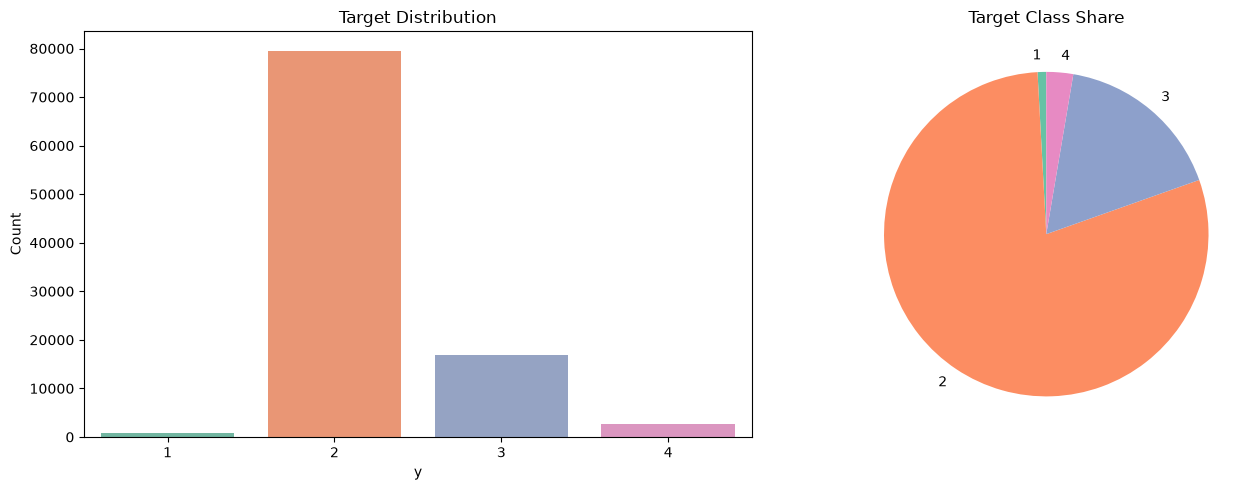

In [63]:
#important y
target_counts = df['y'].value_counts().sort_index()
target_percent = df['y'].value_counts(normalize=True).sort_index() * 100

display(pd.DataFrame({
    'count': target_counts,
    'percent': target_percent
}))

fig, axes = plt.subplots(1,2, figsize=(14,5))

sns.countplot(data=df, x='y', ax=axes[0], palette='Set2')
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('y')
axes[0].set_ylabel('Count')

axes[1].pie(
    target_counts.values,
    labels=target_counts.index,
    startangle=90,
    colors=sns.color_palette('Set2')
)

axes[1].set_title('Target Class Share')

plt.tight_layout()
plt.show()


Mutual Information Scores (Numerical vs y):
year    0.045894
f6      0.035666
f4      0.035264
f7      0.028625
f5      0.025043
f3      0.024425
f16     0.010404
f17     0.003779
f15     0.003417
f19     0.003193
hour    0.001894
f14     0.001057
f20     0.000000
dtype: float64


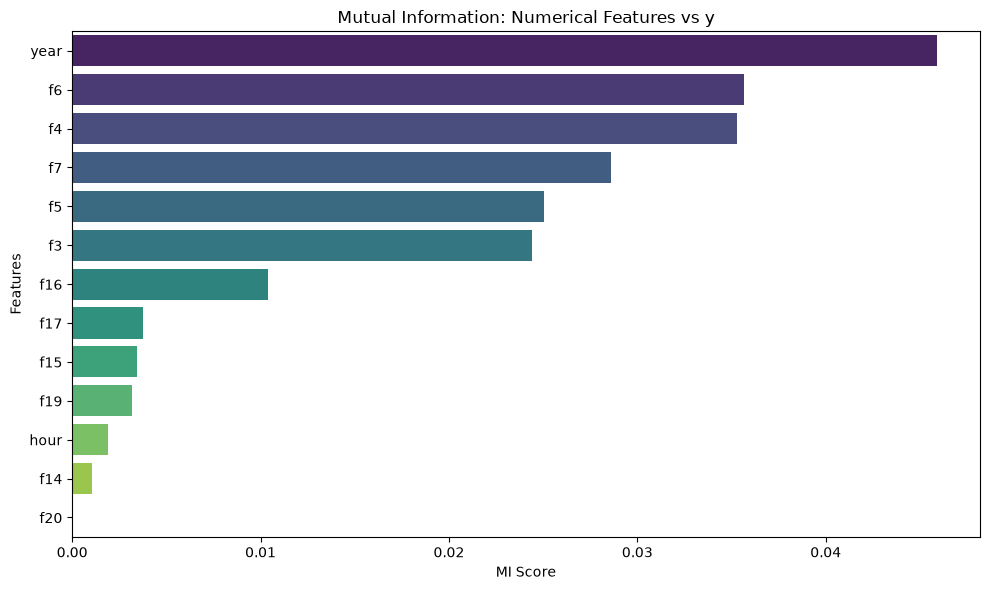

In [64]:
if 'numeric_cols' in locals() and 'y' in df.columns:
    # Data cleaning for MI
    cols_to_use = ['y'] + numeric_cols
    df_mi = df[cols_to_use].dropna()

    if df_mi['y'].nunique() >= 2:
        X_clean = df_mi[numeric_cols]
        y_clean = df_mi['y'].astype(int)

        mi_scores = mutual_info_classif(X_clean, y_clean, random_state=42)
        mi_series = pd.Series(mi_scores, index=numeric_cols).sort_values(ascending=False)

        print("Mutual Information Scores (Numerical vs y):")
        print(mi_series)

        plt.figure(figsize=(10, max(6, len(numeric_cols) * 0.4)))
        sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
        plt.title('Mutual Information: Numerical Features vs y')
        plt.xlabel('MI Score')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()
    else:
        print("Insufficient data: Target 'y' has less than 2 unique classes after dropping NaNs.")
else:
    print("Missing 'numeric_cols' or target 'y' in DataFrame.")


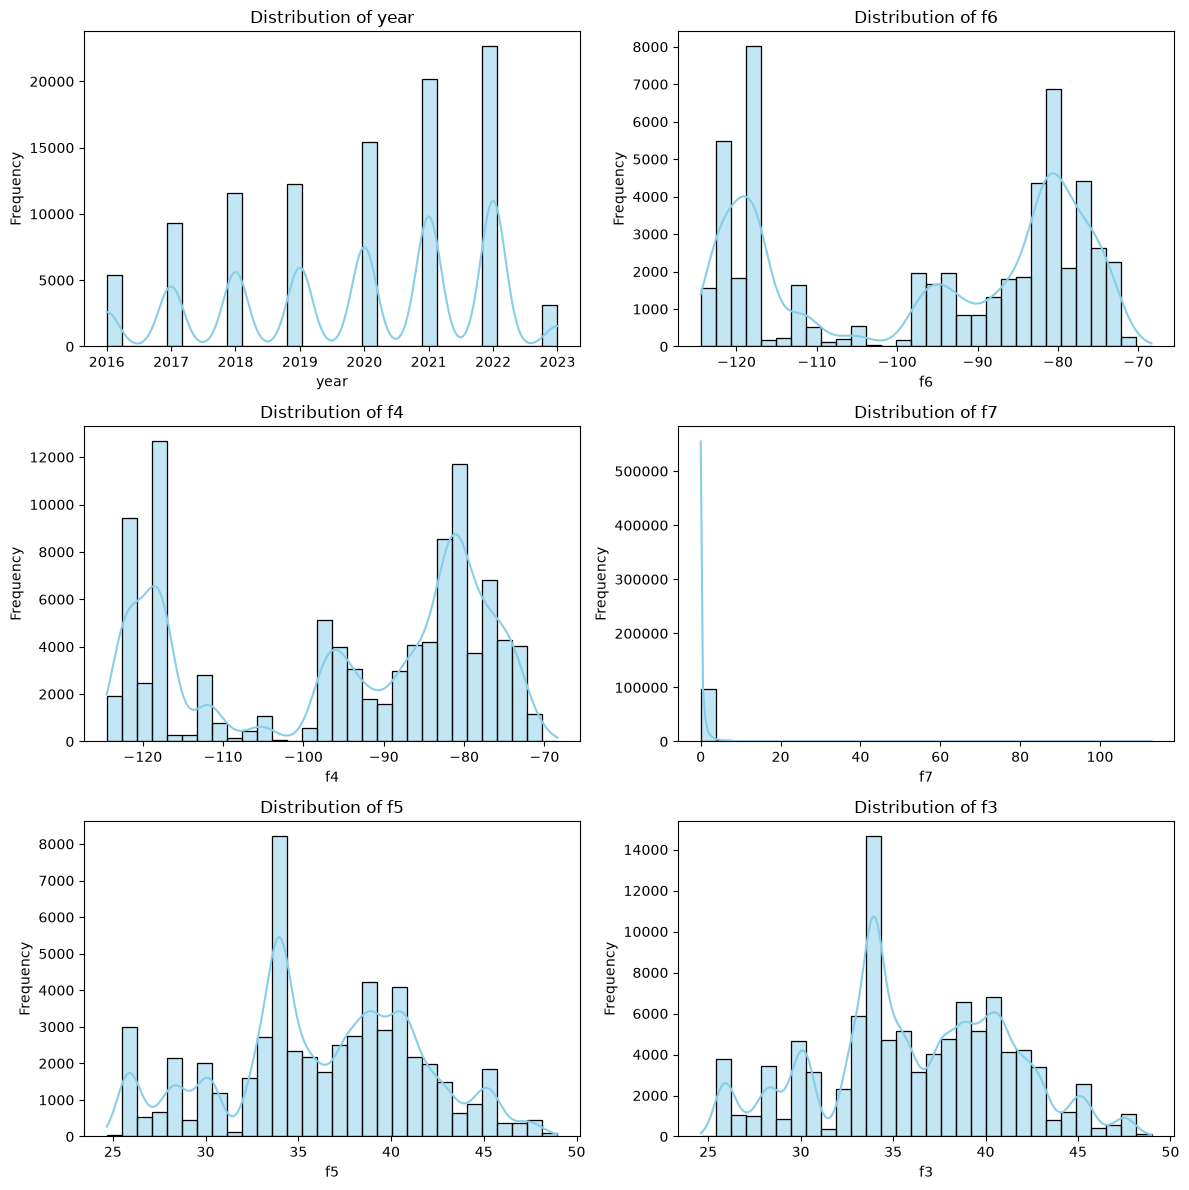

In [65]:
top_6_features = ['year','f6', 'f4', 'f7', 'f5', 'f3']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 12))
axes = axes.flatten()  # flatten to 1D array

for i, feature in enumerate(top_6_features):
    ax = axes[i]
    sns.histplot(df[feature].dropna(), kde=True, bins=30, color='skyblue', ax=ax)
    ax.set_title(f'Distribution of {feature}')
    ax.set_xlabel(feature)
    ax.set_ylabel('Frequency')

# Remove the empty subplot if we have 5 features and 6 subplots (3x2)
if len(top_6_features) < len(axes):
    for j in range(len(top_6_features), len(axes)):
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Mutual Information Scores (Categorical vs y):
f12          0.123451
f8           0.117045
f1           0.093926
f9           0.071124
f13          0.069225
f10          0.058267
f11          0.029100
f21          0.023948
f18          0.017133
month        0.011144
dayofweek    0.005081
dtype: float64


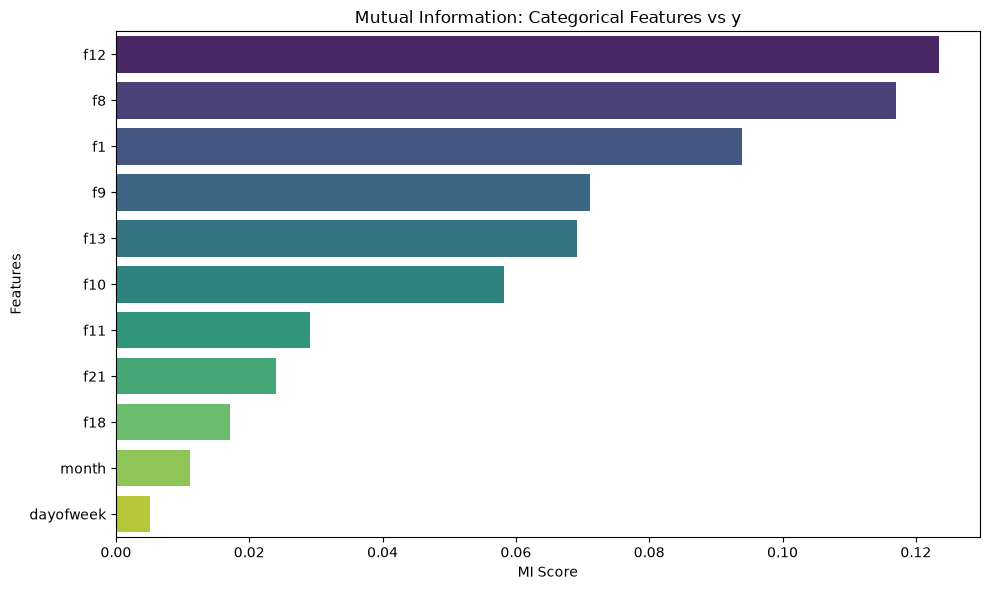

In [66]:
if 'categorical_cols' in locals() and 'y' in df.columns:
    df_clean = df[['y'] + categorical_cols].dropna(subset=['y'])
    
    if df_clean['y'].nunique() >= 2:
        df_encoded = pd.DataFrame()
        for col in categorical_cols:
            df_encoded[col] = df_clean[col].astype('category').cat.codes

        mi_scores = mutual_info_classif(df_encoded, df_clean['y'].astype(int), random_state=42)
        mi_series = pd.Series(mi_scores, index=categorical_cols).sort_values(ascending=False)

        print("Mutual Information Scores (Categorical vs y):")
        print(mi_series)

        plt.figure(figsize=(10, max(6, len(categorical_cols) * 0.4)))
        sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
        plt.title('Mutual Information: Categorical Features vs y')
        plt.xlabel('MI Score')
        plt.ylabel('Features')
        plt.tight_layout()
        plt.show()
    else:
        print("Target 'y' must have at least 2 classes after removing missing values.")
else:
    print("Missing 'categorical_cols' or target 'y' in DataFrame.")


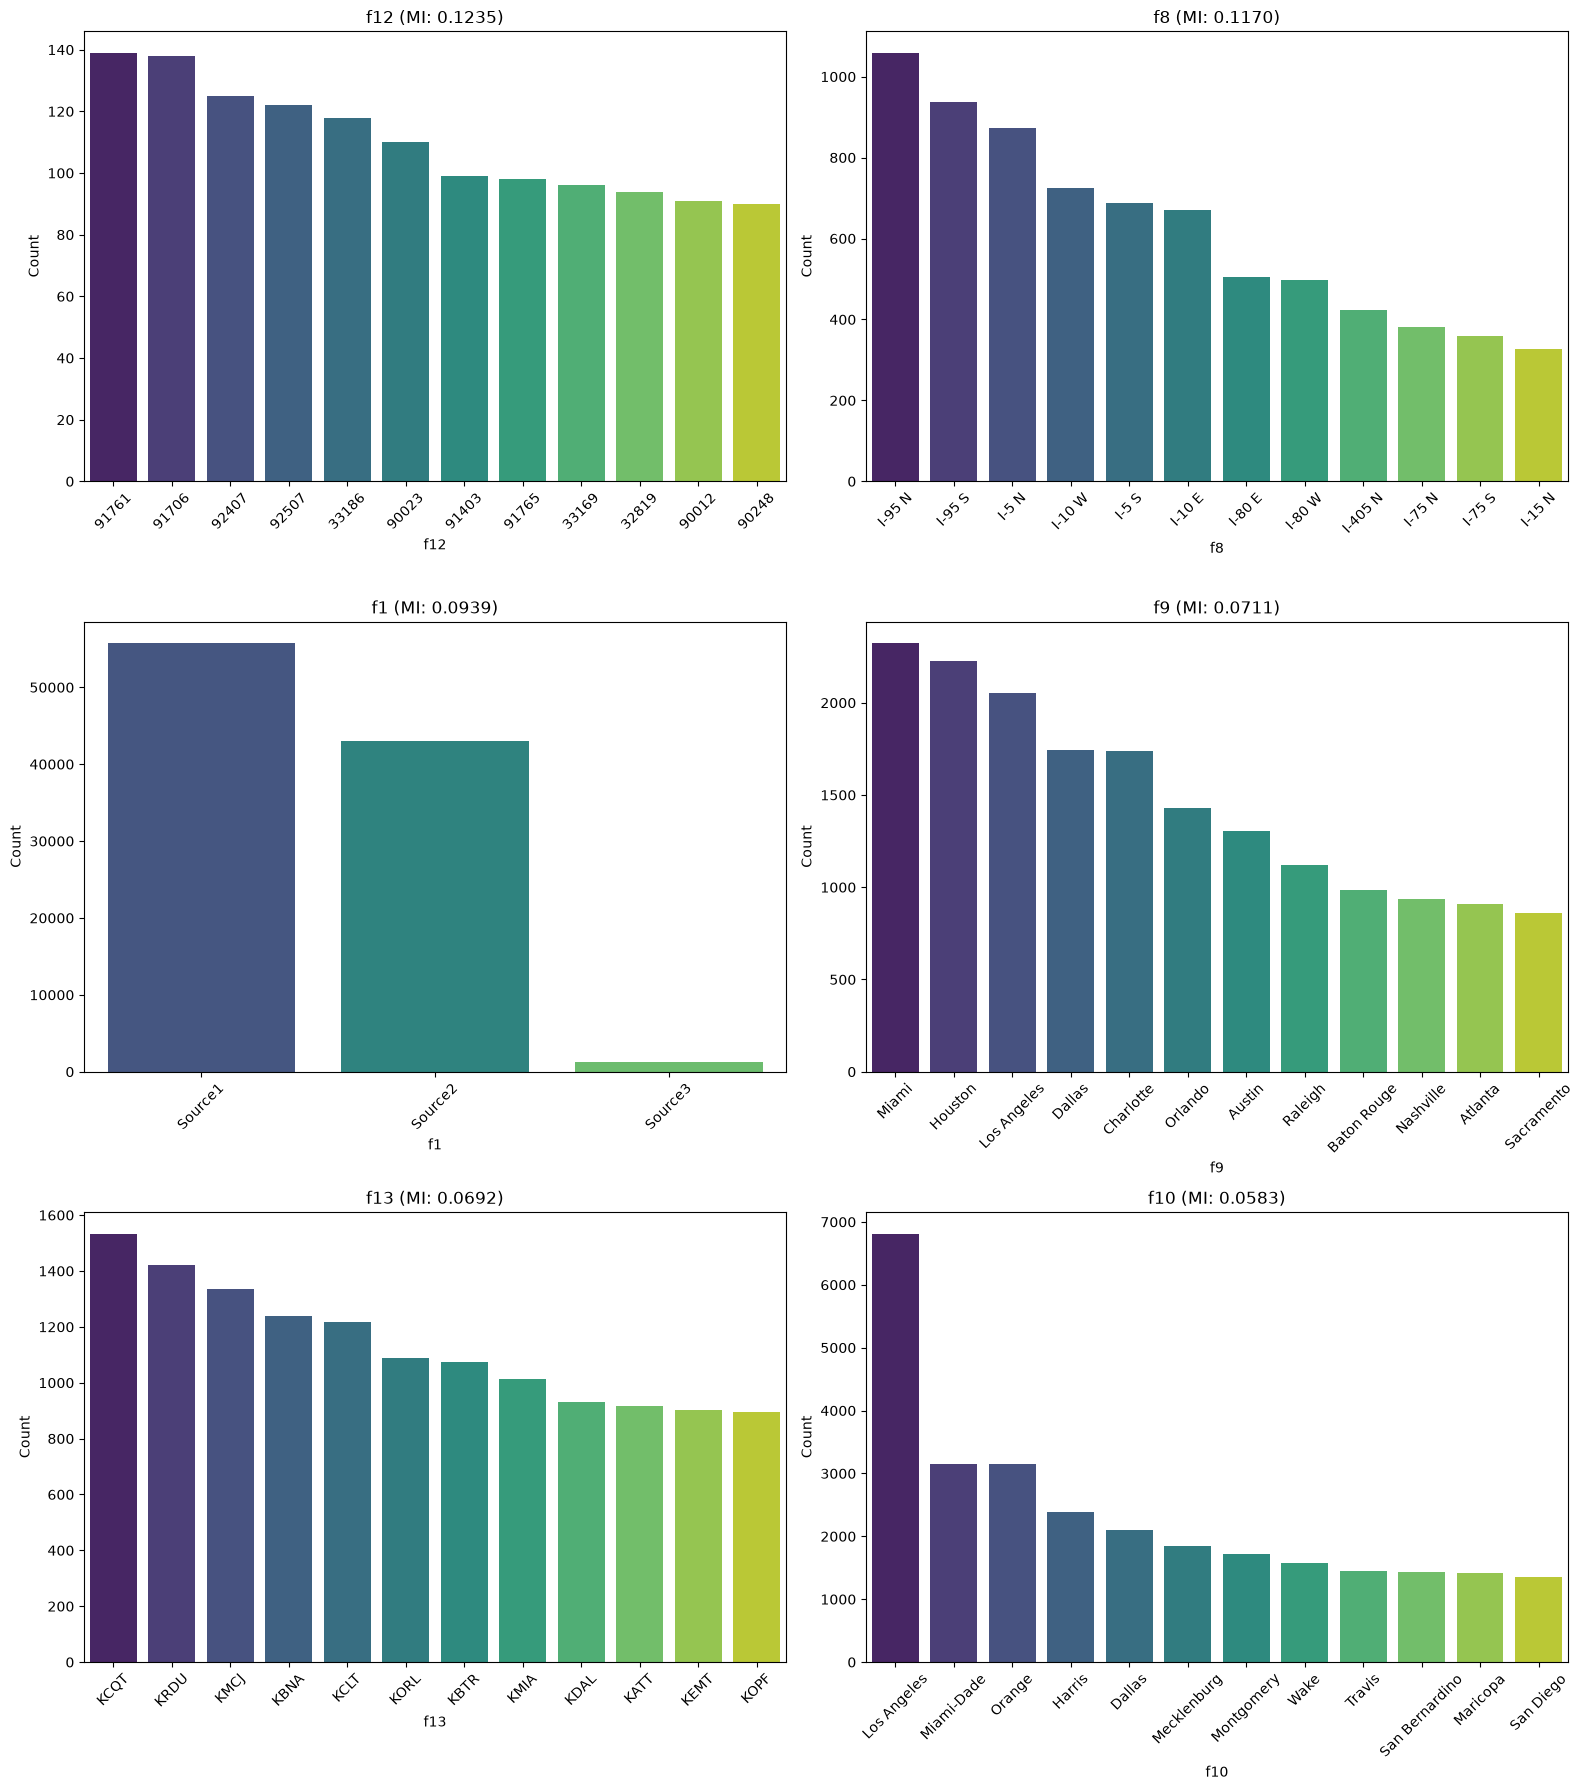

In [67]:
top_6_cat = ['f12', 'f8', 'f1', 'f9', 'f13', 'f10']

fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 18))
axes = axes.flatten()

for i, feature in enumerate(top_6_cat):
    counts = df[feature].value_counts().head(12)
    
    sns.barplot(x=counts.index, y=counts.values, palette='viridis', ax=axes[i])
    axes[i].set_title(f'{feature} (MI: {mi_series[feature]:.4f})')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=45)  # Rotate labels for readability

plt.tight_layout()
plt.show()

Mutual Information Scores (Boolean Features vs y):
f29    0.008877
f31    0.005530
f33    0.004817
f34    0.003389
f27    0.003232
f22    0.002526
f32    0.002233
f23    0.001328
f28    0.000212
f25    0.000159
f24    0.000000
f26    0.000000
f30    0.000000
dtype: float64


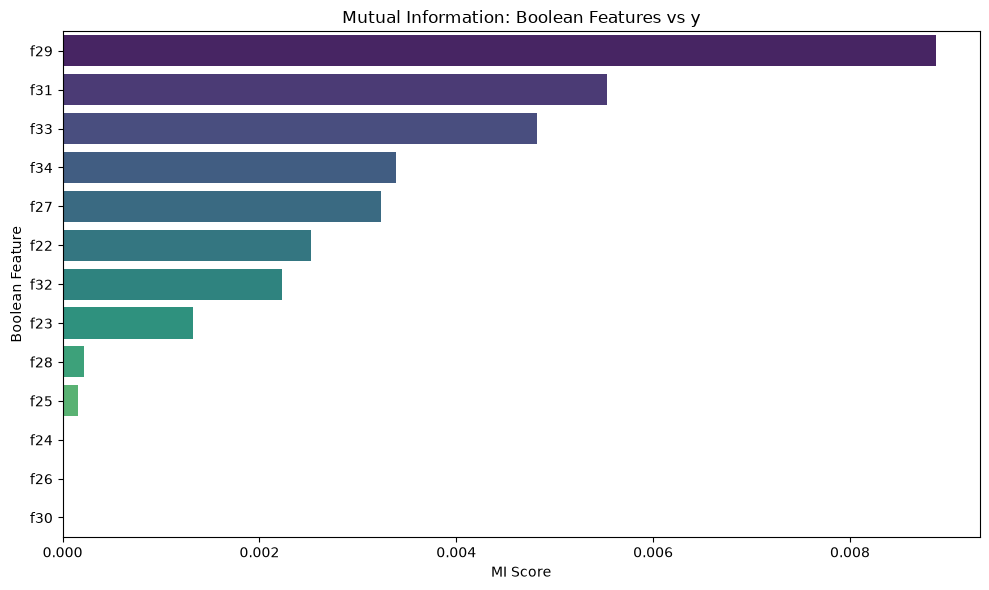

In [68]:

if 'bool_cols' in locals() and bool_cols and 'y' in df.columns:
    valid_bool_cols = [c for c in bool_cols if c in df.columns]

    df_mi = df[valid_bool_cols + ['y']].dropna()
    if df_mi['y'].nunique() >= 2 and valid_bool_cols:
        mi_scores = mutual_info_classif(df_mi[valid_bool_cols], df_mi['y'].astype(int), random_state=42)
        mi_series = pd.Series(mi_scores, index=valid_bool_cols).sort_values(ascending=False)

        print("Mutual Information Scores (Boolean Features vs y):")
        print(mi_series)

        plt.figure(figsize=(10, max(6, len(valid_bool_cols) * 0.4)))
        sns.barplot(x=mi_series.values, y=mi_series.index, palette='viridis')
        plt.title('Mutual Information: Boolean Features vs y')
        plt.xlabel('MI Score')
        plt.ylabel('Boolean Feature')
        plt.tight_layout()
        plt.show()
    else:
        print("Insufficient valid data for Mutual Information analysis.")
elif 'y' not in df.columns:
    print("Missing target column 'y'.")
else:
    print("No boolean columns found.")


In [69]:
# Check distribution of boolean features
bool_cols = ['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']

for col in bool_cols:
    if col in df.columns:
        print(f"{col}: True={df[col].sum()}, False={len(df) - df[col].sum()}, %True={df[col].mean()*100:.1f}%")

f22: True=1234, False=98766, %True=1.2%
f23: True=47, False=99953, %True=0.0%
f24: True=7315, False=92685, %True=7.3%
f25: True=886, False=99114, %True=0.9%
f26: True=3, False=99997, %True=0.0%
f27: True=2919, False=97081, %True=2.9%
f28: True=104, False=99896, %True=0.1%
f29: True=14681, False=85319, %True=14.7%
f30: True=0, False=100000, %True=0.0%
f31: True=31141, False=68859, %True=31.1%
f32: True=26432, False=73568, %True=26.4%
f33: True=21323, False=78677, %True=21.3%
f34: True=17476, False=82524, %True=17.5%


Binary columns: ['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']


,true_count,false_count
f22,1234,98766
f23,47,99953
f24,7315,92685
f25,886,99114
f26,3,99997
f27,2919,97081
f28,104,99896
f29,14681,85319
f30,0,100000
f31,31141,68859


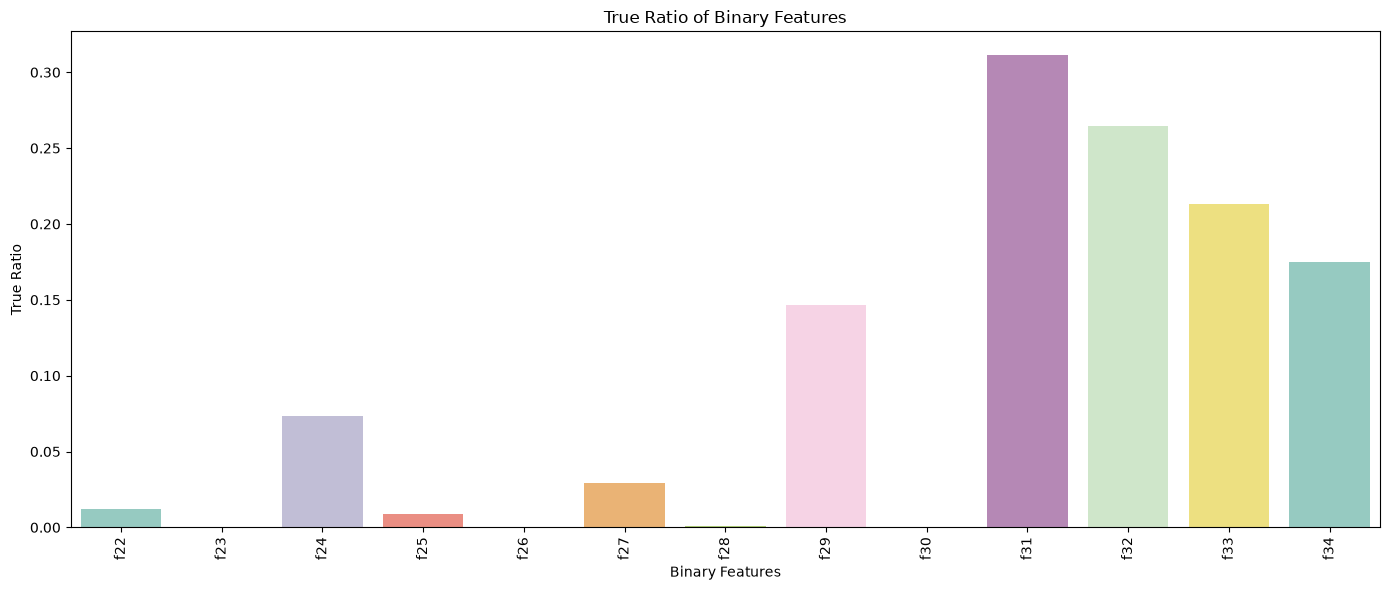

In [70]:
binary_cols = [col for col in df.columns if df[col].dropna().isin([True, False]).all()]
print('Binary columns:', binary_cols)

binary_summary = pd.DataFrame({
    'true_count': df[binary_cols].sum(numeric_only=True),
    'false_count': df[binary_cols].shape[0] - df[binary_cols].sum(numeric_only=True)
    
})
display(binary_summary)

binary_summary['true_ratio'] = binary_summary['true_count'] / (binary_summary['true_count'] + binary_summary['false_count'])
plt.figure(figsize=(14, 6))
sns.barplot(x=binary_summary.index, y=binary_summary['true_ratio'], palette='Set3')
plt.xticks(rotation=90)
plt.title('True Ratio of Binary Features')
plt.ylabel('True Ratio')
plt.xlabel('Binary Features')
plt.tight_layout()
plt.show()


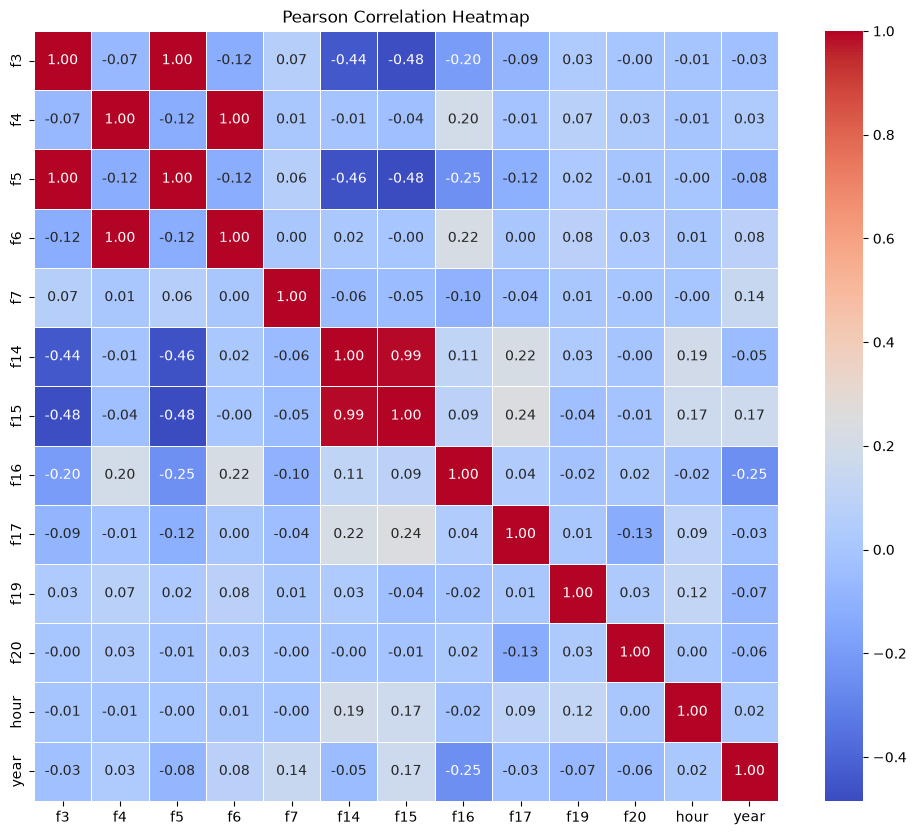

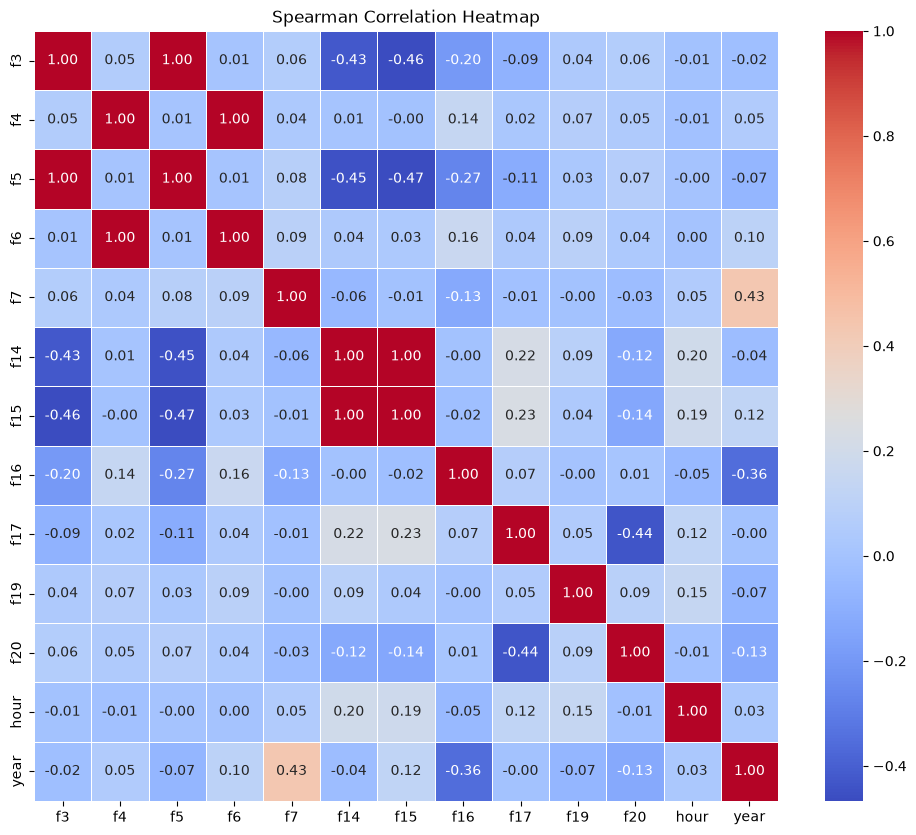

In [71]:
if numeric_cols:
    # Pearson Correlation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(method='pearson'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Pearson Correlation Heatmap')
    plt.show()

    # Spearman Correl ation Heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(df[numeric_cols].corr(method='spearman'), annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
    plt.title('Spearman Correlation Heatmap')
    plt.show()
else:
    print("No numerical columns found for correlation analysis.")


Categorical columns used: ['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'dayofweek', 'month']


,f1,f8,f9,f10,f11,f12,f13,f18,f21,dayofweek,month
f1,1.000000,0.827379,0.628127,0.383875,0.225348,0.856106,0.432176,0.230635,0.260120,0.101111,0.107680
f8,0.827379,1.000000,0.847599,0.869074,0.893715,0.915701,0.859576,0.830592,0.809707,0.819824,0.821575
f9,0.628127,0.847599,1.000000,0.925845,0.952914,0.998856,0.896181,0.587862,0.571433,0.602695,0.593084
f10,0.383875,0.869074,0.925845,1.000000,0.909489,0.992560,0.840003,0.362221,0.376324,0.354109,0.346548
f11,0.225348,0.893715,0.952914,0.909489,1.000000,1.000000,0.972637,0.130461,0.132907,0.110856,0.094925
f12,0.856106,0.915701,0.998856,0.992560,1.000000,1.000000,1.000000,0.878915,0.896204,0.880727,0.878189
f13,0.432176,0.859576,0.896181,0.840003,0.972637,1.000000,1.000000,0.425852,0.495894,0.411171,0.408043
f18,0.230635,0.830592,0.587862,0.362221,0.130461,0.878915,0.425852,1.000000,0.167359,0.077800,0.084594
f21,0.260120,0.809707,0.571433,0.376324,0.132907,0.896204,0.495894,0.167359,1.000000,0.108403,0.129512
dayofweek,0.101111,0.819824,0.602695,0.354109,0.110856,0.880727,0.411171,0.077800,0.108403,1.000000,0.037250


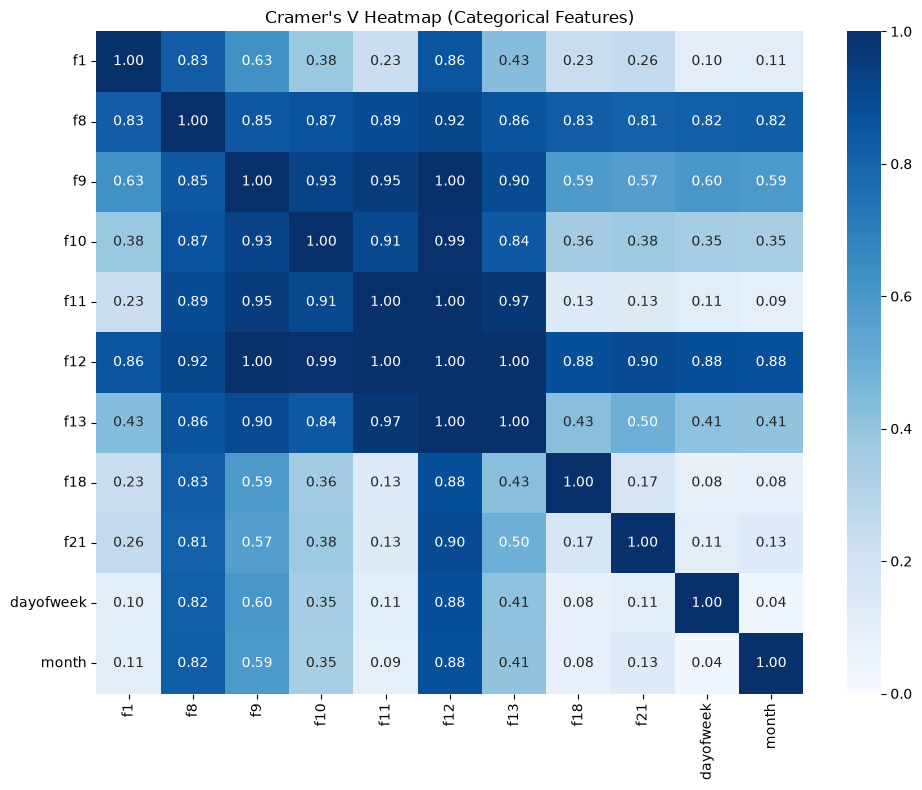

In [72]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    if confusion_matrix.empty or confusion_matrix.to_numpy().sum() == 0:
        return np.nan
    
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.to_numpy().sum()
    r, k = confusion_matrix.shape
    
    if min(r - 1, k - 1) <= 0:
        return 0.0
    return np.sqrt((chi2 / n) / min(r - 1, k - 1))

sample_df = df.sample(min(5000, len(df)), random_state=42)
cat_cols = [c for c in sample_df.select_dtypes(include=['object', 'category']).columns if c != 'f2']

print(f"Categorical columns used: {cat_cols}")

cramers_matrix = pd.DataFrame(np.eye(len(cat_cols)), index=cat_cols, columns=cat_cols)

for i, col1 in enumerate(cat_cols):
    for j, col2 in enumerate(cat_cols):
        if i < j:
            val = cramers_v(sample_df[col1], sample_df[col2])
            cramers_matrix.loc[col1, col2] = val
            cramers_matrix.loc[col2, col1] = val

display(cramers_matrix)

plt.figure(figsize=(10, 8))
sns.heatmap(cramers_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".2f")
plt.title("Cramer's V Heatmap (Categorical Features)")
plt.tight_layout()
plt.show()


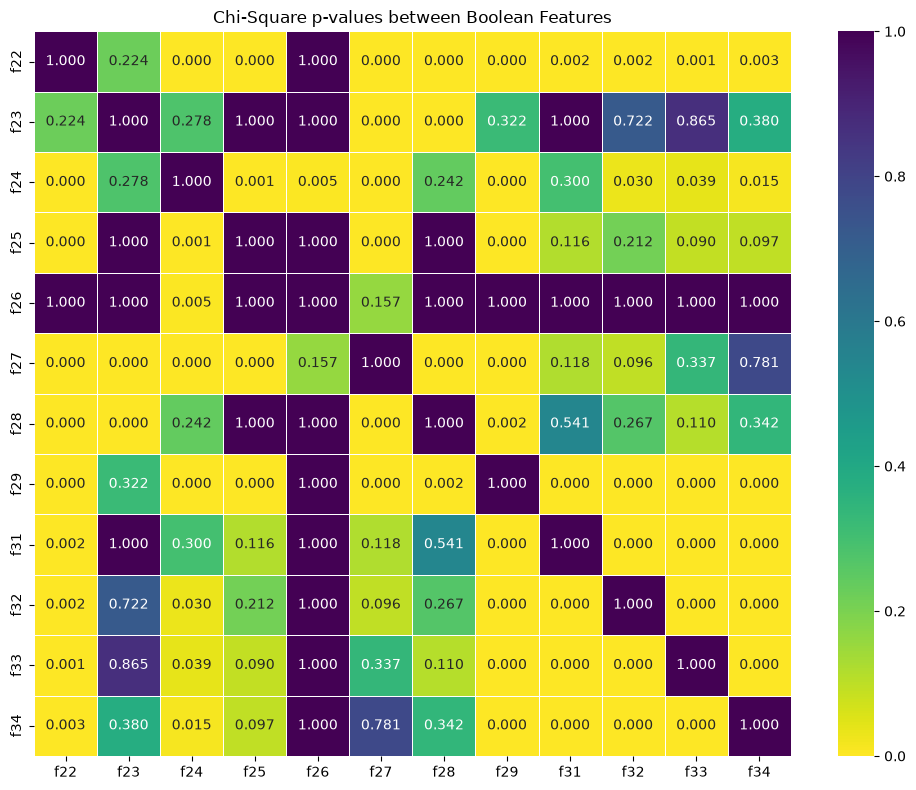

In [73]:
if 'bool_cols' in locals() and len(bool_cols) >= 2:
    valid_bool_cols = [c for c in bool_cols if c in df.columns and df[c].nunique(dropna=True) > 1]

    if len(valid_bool_cols) >= 2:
        pval_matrix = pd.DataFrame(1.0, index=valid_bool_cols, columns=valid_bool_cols)

        for i, col1 in enumerate(valid_bool_cols):
            for col2 in valid_bool_cols[i + 1:]:
                table = pd.crosstab(df[col1], df[col2])

                if table.shape[0] > 1 and table.shape[1] > 1:
                    _, p_val, _, _ = chi2_contingency(table)
                    pval_matrix.loc[col1, col2] = p_val
                    pval_matrix.loc[col2, col1] = p_val


        plt.figure(figsize=(10, 8))
        sns.heatmap(pval_matrix, annot=True, cmap='viridis_r', fmt=".3f", linewidths=.5)
        plt.title('Chi-Square p-values between Boolean Features')
        plt.tight_layout()
        plt.show()
    else:
        print("Not enough valid boolean columns for Chi-Square test.")
else:
    print("Missing 'bool_cols' or not enough boolean columns.")


# CLEANING

,missing_count,missing_percent
f6,44256,44.256
f5,44256,44.256
f20,28631,28.631
f15,25982,25.982
f19,7375,7.375
f18,2227,2.227
f17,2207,2.207
f21,2182,2.182
f14,2074,2.074
f16,1788,1.788


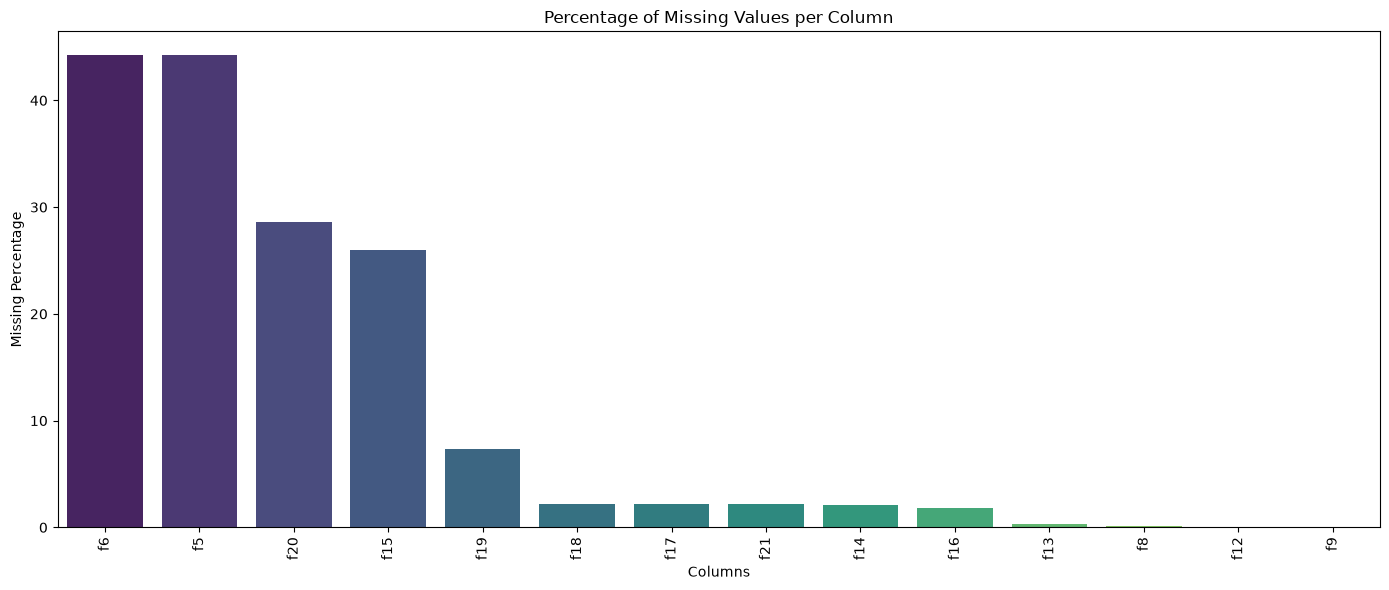

In [74]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_percent = (df.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame({
    'missing_count': missing_count,
    'missing_percent': missing_percent
})

missing_df = missing_df[missing_df['missing_count'] > 0]

display(missing_df)

plt.figure(figsize=(14,6))
sns.barplot(x=missing_df.index, y=missing_df['missing_percent'], palette='viridis')

plt.xticks(rotation=90)
plt.title('Percentage of Missing Values per Column')
plt.ylabel('Missing Percentage')
plt.xlabel('Columns')

plt.tight_layout()
plt.show()


In [75]:
outlier_counts = {}

for col in numeric_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    outlier_counts[col] = outliers

outlier_df = pd.DataFrame.from_dict(outlier_counts, orient="index", columns=["Outlier Count"])

outlier_df.sort_values("Outlier Count", ascending=False)


,Outlier Count
f17,19203
f7,12529
f20,6907
f16,5836
f19,2708
f14,625
f15,558
f4,0
f3,0
f6,0


In [76]:
unique_counts = df.nunique().sort_values(ascending=False)

display(unique_counts.to_frame(name='unique_values'))

,unique_values
f3,90725
f4,90686
f6,51577
f5,51573
f12,36879
f8,32428
f9,6406
f7,6177
f13,1616
f10,1303


In [77]:
near_constant = []

for col in df.columns:
    
    top_freq = df[col].value_counts(normalize=True).values[0]
    
    if top_freq > 0.95:
        near_constant.append(col)

print("Near constant features:")
print(near_constant)


Near constant features:
['f22', 'f23', 'f25', 'f26', 'f27', 'f28', 'f30']


In [78]:
original_rows = len(df)

df.drop_duplicates(inplace=True)

print("Removed rows:", original_rows - len(df))
print("New shape:", df.shape)


Removed rows: 136
New shape: (99864, 38)


In [79]:
row_threshold = 0.2

df = df.dropna(thresh=int((1 - row_threshold) * df.shape[1]))

print("Shape after removing highly-missing rows:", df.shape)



Shape after removing highly-missing rows: (99098, 38)


In [80]:
low_nan_cols = [col for col in df.columns if 0 < df[col].isnull().mean() < 0.05]

df.dropna(subset=low_nan_cols, inplace=True)

print("Shape after removing rows with small NaN columns:", df.shape)


Shape after removing rows with small NaN columns: (96417, 38)


In [81]:
missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing_values,
    "Missing Percent": missing_percent
})

missing_table = missing_table[missing_table["Missing Count"] > 0]

missing_table = missing_table.sort_values("Missing Percent", ascending=False)

missing_table


,Missing Count,Missing Percent
f5,43053,44.652914
f6,43053,44.652914
f20,26584,27.571901
f15,23102,23.960505
f19,4902,5.084166


In [82]:
corr_3_5 = df['f3'].corr(df['f5'])
corr_4_6 = df['f4'].corr(df['f6'])
corr_14_15 = df['f14'].corr(df['f15'])

print(f"Correlation between f3 and f5: {corr_3_5:.4f}")
print(f"Correlation between f4 and f6: {corr_4_6:.4f}")
print(f"Correlation between f14 and f15: {corr_14_15:.4f}")

df.drop(columns=['f5', 'f6', 'f15'], inplace=True)

print("\nColumns 'f5', 'f6', and 'f15' have been dropped.")
print("Current columns in dataframe:", df.columns.tolist())


Correlation between f3 and f5: 1.0000
Correlation between f4 and f6: 1.0000
Correlation between f14 and f15: 0.9938

Columns 'f5', 'f6', and 'f15' have been dropped.
Current columns in dataframe: ['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f20', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y', 'hour', 'dayofweek', 'month', 'year']


In [83]:
df.shape

(96417, 35)

In [84]:
cols = ['f19', 'f20']

print("Shape:", df[cols].shape)

print("\nMissing values:")
print(df[cols].isna().sum())

print("\nMissing percentage:")
print(df[cols].isna().mean() * 100)

print("\nDescriptive statistics:")
print(df[cols].describe())

print("\nCorrelation:")
print(df[cols].corr())


Shape: (96417, 2)

Missing values:
f19     4902
f20    26584
dtype: int64

Missing percentage:
f19     5.084166
f20    27.571901
dtype: float64

Descriptive statistics:
                f19           f20
count  91515.000000  69833.000000
mean       7.682247      0.007857
std        5.880811      0.087978
min        0.000000      0.000000
25%        4.600000      0.000000
50%        7.000000      0.000000
75%       10.400000      0.000000
max      812.000000      9.990000

Correlation:
          f19       f20
f19  1.000000  0.032516
f20  0.032516  1.000000


In [85]:

X = df[['f19','f20']]
y = df['y']

X = X.fillna(X.median())

mi = mutual_info_classif(X, y)

for col, score in zip(X.columns, mi):
    print(f"{col}: {score}")



f19: 0.031445034590178444
f20: 0.0016116790095865863


In [86]:
df['f19'] = df['f19'].fillna(df['f19'].median())

df.drop(columns=['f20'], inplace=True)

print("f19 missing values filled with median and f20 dropped.")
print("Current columns:", df.columns.tolist())


f19 missing values filled with median and f20 dropped.
Current columns: ['f1', 'f3', 'f4', 'f7', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f14', 'f16', 'f17', 'f18', 'f19', 'f21', 'f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34', 'y', 'hour', 'dayofweek', 'month', 'year']


In [88]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=["str"]).columns.tolist()
bool_cols = df.select_dtypes(include=["bool"]).columns.tolist()

print("Numeric columns:", len(numeric_cols))
print(numeric_cols)

print("\nCategorical columns:", len(categorical_cols))
print(categorical_cols)

print("\nBoolean columns:", len(bool_cols))
print(bool_cols)


Numeric columns: 10
['f3', 'f4', 'f7', 'f14', 'f16', 'f17', 'f19', 'y', 'hour', 'year']

Categorical columns: 11
['f1', 'f8', 'f9', 'f10', 'f11', 'f12', 'f13', 'f18', 'f21', 'dayofweek', 'month']

Boolean columns: 13
['f22', 'f23', 'f24', 'f25', 'f26', 'f27', 'f28', 'f29', 'f30', 'f31', 'f32', 'f33', 'f34']
